In [11]:
!pip install opendrift
from opendrift.models.oceandrift import OceanDrift
from opendrift.readers.reader_netCDF_CF_generic import Reader
from datetime import datetime, timedelta




[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [12]:
import rasterio
import numpy as np

def extract_oil_coordinates(tiff_path):
    with rasterio.open(tiff_path) as src:
        mask = src.read(1)  # first band
        transform = src.transform

        oil_pixels = np.argwhere(mask > 0)

        lons = []
        lats = []

        for row, col in oil_pixels:
            lon, lat = rasterio.transform.xy(transform, row, col)
            lons.append(lon)
            lats.append(lat)

    return np.array(lons), np.array(lats)

lons, lats = extract_oil_coordinates("/Volumes/Windows8_OS/Dataset/Dataset-OG/Test/Mask/Oil/00000_segmentation.tif")

18:17:22 WARNING py.warnings:110: /Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)



In [13]:
o = OceanDrift(loglevel=20)


18:18:19 INFO    opendrift:576: OpenDriftSimulation initialised (version 1.14.8)


In [14]:
from opendrift.readers.reader_netCDF_CF_generic import Reader

wind_reader = Reader(
    "Drifts/wind_data2.nc",
    standard_name_mapping={
        'u10': 'x_wind',
        'v10': 'y_wind'
    }
)

o.add_reader(wind_reader)


18:18:19 INFO    opendrift.readers:63: Opening file with xr.open_dataset
18:18:19 INFO    opendrift.readers.reader_netCDF_CF_generic:332: Detected dimensions: {'time': 'valid_time', 'x': 'longitude', 'y': 'latitude'}


In [15]:
print(wind_reader)


Reader: Drifts/wind_data2.nc
Projection: 
  +proj=latlong
Coverage: [degrees]
  xmin: 37.500000   xmax: 39.500000   step: 0.25   numx: 9
  ymin: 19.500000   ymax: 21.500000   step: 0.25   numy: 9
  Corners (lon, lat):
    ( 37.50,  21.50)  ( 39.50,  21.50)
    ( 37.50,  19.50)  ( 39.50,  19.50)
Vertical levels [m]: 
  Not specified
Available time range:
  start: 2025-01-01 07:00:00   end: 2025-01-04 14:00:00   step: 1:00:00
    80 times (60 missing)
Variables (1 ensemble members):
  x_wind
  y_wind
  wind_speed - derived from ['x_wind', 'y_wind']



In [17]:
import rasterio

with rasterio.open("/Volumes/Windows8_OS/Dataset/Dataset-OG/Test/Mask/Oil/00000_segmentation.tif") as src:
    print("CRS:", src.crs)

18:19:45 WARNING py.warnings:110: /Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)



CRS: None


In [16]:
from datetime import datetime, timedelta

idx = np.random.choice(len(lons), size=2000, replace=False)
o.seed_elements(
    lon=lons[idx],
    lat=lats[idx],
    time=datetime(2025,1,1,7)
)


18:18:25 INFO    opendrift.models.basemodel.environment:203: Adding a global landmask from GSHHG
18:18:25 INFO    opendrift.models.basemodel.environment:227: Fallback values will be used for the following variables which have no readers: 
18:18:25 INFO    opendrift.models.basemodel.environment:230: 	x_sea_water_velocity: 0.000000
18:18:25 INFO    opendrift.models.basemodel.environment:230: 	y_sea_water_velocity: 0.000000
18:18:25 INFO    opendrift.models.basemodel.environment:230: 	sea_surface_height: 0.000000
18:18:25 INFO    opendrift.models.basemodel.environment:230: 	upward_sea_water_velocity: 0.000000
18:18:25 INFO    opendrift.models.basemodel.environment:230: 	ocean_vertical_diffusivity: 0.000000
18:18:25 INFO    opendrift.models.basemodel.environment:230: 	sea_surface_wave_significant_height: 0.000000
18:18:25 INFO    opendrift.models.basemodel.environment:230: 	sea_surface_wave_stokes_drift_x_velocity: 0.000000
18:18:25 INFO    opendrift.models.basemodel.environment:230: 	sea_

ValueError: Latitude must be between -90 and 90 degrees

In [9]:
o.run(
    duration=timedelta(hours=24),
    time_step=900,
    outfile="oil_drift_output.nc"
)


18:15:30 INFO    opendrift:1810: Skipping environment variable ocean_vertical_diffusivity because of condition ['drift:vertical_mixing', 'is', False]
18:15:30 INFO    opendrift:1810: Skipping environment variable ocean_mixed_layer_thickness because of condition ['drift:vertical_mixing', 'is', False]
18:15:30 INFO    opendrift:1821: Storing previous values of element property lon because of condition (('general:coastline_action', 'in', ['stranding', 'previous']), 'or', ('general:seafloor_action', 'in', ['previous']))
18:15:30 INFO    opendrift:1821: Storing previous values of element property lat because of condition (('general:coastline_action', 'in', ['stranding', 'previous']), 'or', ('general:seafloor_action', 'in', ['previous']))
18:15:30 INFO    opendrift:1829: Storing previous values of environment variable sea_surface_height because of condition ['drift:vertical_advection', 'is', True]
18:15:30 INFO    opendrift:952: Using existing reader for land_binary_mask to move elements to 

<xarray.Dataset> Size: 9MB
Dimensions:                                   (trajectory: 1000, time: 97)
Coordinates:
  * trajectory                                (trajectory) int32 4kB 0 1 ... 999
  * time                                      (time) datetime64[ns] 776B 2025...
Data variables: (12/21)
    status                                    (trajectory, time) float64 776kB ...
    moving                                    (trajectory, time) float64 776kB ...
    age_seconds                               (trajectory, time) float32 388kB ...
    origin_marker                             (trajectory, time) float64 776kB ...
    lon                                       (trajectory, time) float32 388kB ...
    lat                                       (trajectory, time) float32 388kB ...
    ...                                        ...
    upward_sea_water_velocity                 (trajectory, time) float32 388kB ...
    sea_surface_wave_significant_height       (trajectory, time) float32 388kB ...
    sea_surface_wave_stokes_drift_x_velocity  (trajectory, time) float32 388kB ...
    sea_surface_wave_stokes_drift_y_velocity  (trajectory, time) float32 388kB ...
    sea_floor_depth_below_sea_level           (trajectory, time) float32 388kB ...
    land_binary_mask                          (trajectory, time) float32 388kB ...
Attributes: (12/119)
    Conventions:                                                           CF...
    standard_name_vocabulary:                                              CF...
    featureType:                                                           tr...
    title:                                                                 Op...
    summary:                                                               Ou...
    keywords:                                                              tr...
    ...                                                                    ...
    geospatial_lon_units:                                                  de...
    geospatial_lon_resolution:                                             point
    runtime:                                                               0:...
    geospatial_vertical_min:                                               0.0
    geospatial_vertical_max:                                               0.0
    geospatial_vertical_positive:                                          up

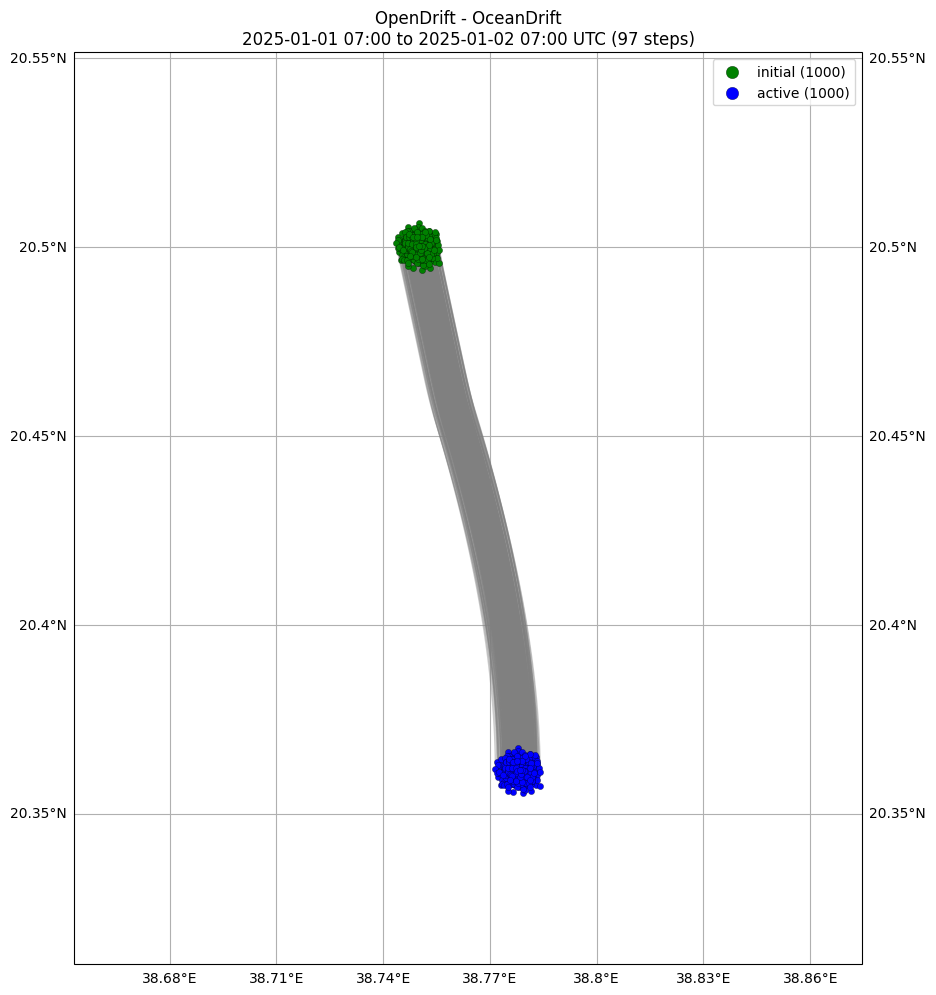

16:50:16 INFO    opendrift:3128: Preparing animation for notebook....


16:54:01 INFO    opendrift:3101: Time to make animation: 0:03:47.395386


In [21]:
o.plot()
o.animation()


17:31:30 INFO    opendrift:576: OpenDriftSimulation initialised (version 1.14.8)
17:31:30 INFO    opendrift.readers:63: Opening file with xr.open_dataset
17:31:30 INFO    opendrift.readers.reader_netCDF_CF_generic:332: Detected dimensions: {'time': 'valid_time', 'x': 'longitude', 'y': 'latitude'}
17:31:30 INFO    opendrift.readers:63: Opening file with xr.open_dataset
17:31:30 INFO    opendrift.readers.reader_netCDF_CF_generic:299: Grid coordinates are detected, but proj4 string not given: assuming latlong
17:31:30 INFO    opendrift.readers.reader_netCDF_CF_generic:332: Detected dimensions: {'time': 'time', 'z': 'depth', 'y': 'latitude', 'x': 'longitude'}
17:31:30 INFO    opendrift.models.basemodel.environment:203: Adding a global landmask from GSHHG
17:31:30 INFO    opendrift.models.basemodel.environment:227: Fallback values will be used for the following variables which have no readers: 
17:31:30 INFO    opendrift.models.basemodel.environment:230: 	upward_sea_water_velocity: 0.000000

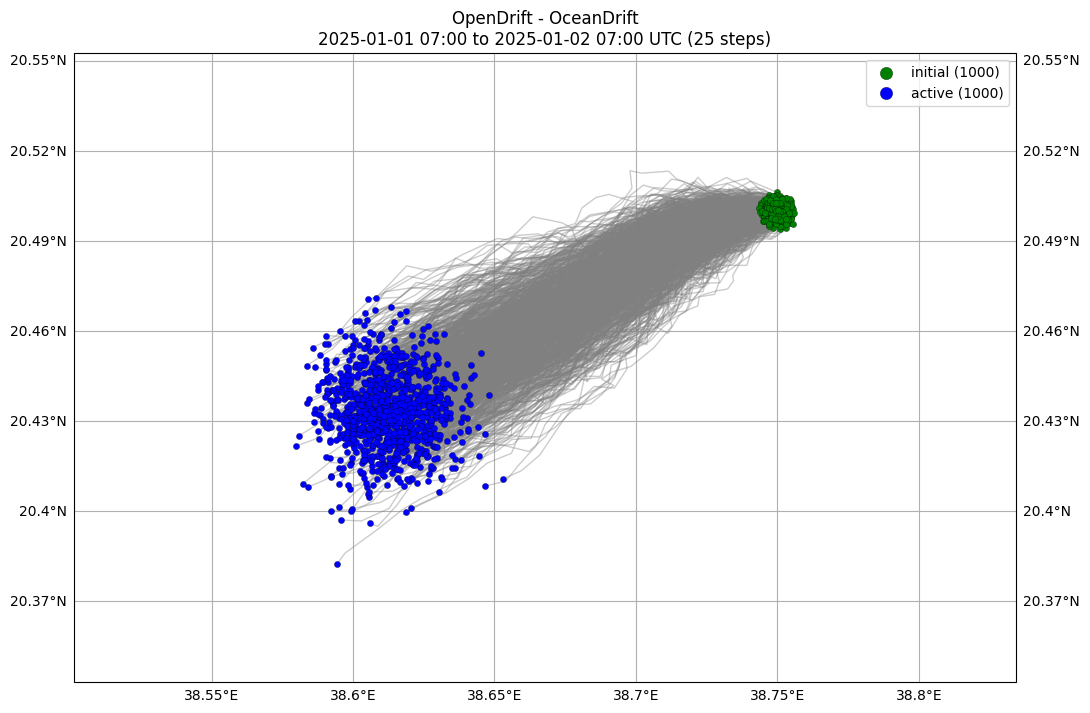

17:31:46 INFO    opendrift:3128: Preparing animation for notebook....


17:32:49 INFO    opendrift:3101: Time to make animation: 0:01:05.007025


In [28]:
from opendrift.models.oceandrift import OceanDrift
from opendrift.readers.reader_netCDF_CF_generic import Reader
from datetime import datetime, timedelta

o = OceanDrift(loglevel=20)

# add wind
wind_reader = Reader(
    r"C:\FinalYear\wind_data2.nc",
    standard_name_mapping={
        'u10': 'x_wind',
        'v10': 'y_wind'
    }
)
o.add_reader(wind_reader)

# add currents
current_reader = Reader(
    r"C:\FinalYear\ocean_current.nc",
    standard_name_mapping={
        'uo': 'x_sea_water_velocity',
        'vo': 'y_sea_water_velocity'
    }
)
o.add_reader(current_reader)

# physics
o.set_config('drift:vertical_mixing', True)
o.set_config('drift:horizontal_diffusivity', 10)

# seed
o.seed_elements(
    lon=38.75,
    lat=20.50,
    radius=219.24,
    number=1000,
    time=datetime(2025,1,1,7)
)

# run
o.run(duration=timedelta(hours=24))

# plot
o.plot()
o.animation()

In [27]:
o = OceanDrift(loglevel=20)


17:29:55 INFO    opendrift:576: OpenDriftSimulation initialised (version 1.14.8)


In [ ]:
o.plot()
o.animation()


In [2]:
import rasterio
import numpy as np

def extract_oil_coordinates(tiff_path):
    with rasterio.open(tiff_path) as src:
        mask = src.read(1)  # first band
        transform = src.transform

        oil_pixels = np.argwhere(mask > 0)

        lons = []
        lats = []

        for row, col in oil_pixels:
            lon, lat = rasterio.transform.xy(transform, row, col)
            lons.append(lon)
            lats.append(lat)

    return np.array(lons), np.array(lats)

In [3]:
lons, lats = extract_oil_coordinates("/Volumes/Windows8_OS/Dataset/Dataset-OG/Test/Mask/Oil/00000_segmentation.tif")

In [4]:
lons, lats

(array([1826.5, 1827.5, 1828.5, ..., 2045.5, 2046.5, 2047.5]),
 array([5.0000e-01, 5.0000e-01, 5.0000e-01, ..., 2.0475e+03, 2.0475e+03,
        2.0475e+03]))